# Strategy comparison: which phasing shape/intensity wins?

**Question:** which phasing shape and intensity wins across variance, bias
and identifiability, not just cost? Folds the old
`10_benefit_table.ipynb`/`11_phasing_strategy.ipynb` pair into one --
`DiscoveryReport` already sweeps a lever grid and scores every candidate on
these exact axes (see `_pick_winner` in `_discovery_report.py`), so this
notebook drives that class directly with a custom `levers` list rather than
reimplementing bias/variance/identifiability measurement by hand the way
the old notebooks had to (before `DiscoveryReport` existed).

Five candidates, on the same canonical scenario as notebook 01: the
historical default (`+/-80%`, uniform, unbalanced), two `edge`+balanced
points (`+/-40%` and `+/-80%`), an `annulus`+balanced point (the "middle"
shape, to check whether it is a cheaper way to get similar rigor), and
Blackout. `DiscoveryReport` requires an unphased baseline first.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from how_wrong_is_your_mmm import Blackout, DiscoveryReport, simulate_spend
from how_wrong_is_your_mmm._dgp import channel_contributions
from how_wrong_is_your_mmm._discovery_report import _safe_improvement

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Same four channels/economics as notebooks 01/02/03/04.
CHANNELS = ["tv", "meta", "search_generic", "tiktok"]
TRUE_MARGINAL_RETURNS = {"tv": 0.5, "meta": 1.0, "search_generic": 1.5, "tiktok": 1.2}
TRUE_SATURATION = {"tv": 0.60, "meta": 0.75, "search_generic": 0.90, "tiktok": 0.70}
TRUE_ADSTOCK = {"tv": 0.50, "meta": 0.30, "search_generic": 0.10, "tiktok": 0.20}

history_df = simulate_spend(
    n_obs=208, correlation=0.7, channels=CHANNELS, seed=0, start_date="2019-01-07"
)
plan_df = simulate_spend(
    n_obs=52, correlation=0.7, channels=CHANNELS, seed=1, start_date="2023-01-09"
)


def all_channels(v):
    return {c: v for c in CHANNELS}


LEVER_ORDER = [
    "unphased",
    "+/-80% (uniform)",
    "+/-40% (edge, balanced)",
    "+/-80% (edge, balanced)",
    "+/-80% (annulus, balanced)",
    "Blackout",
]
levers = [
    ("unphased", all_channels(0.0), "uniform", False),
    ("+/-80% (uniform)", all_channels(80.0), "uniform", False),
    ("+/-40% (edge, balanced)", all_channels(40.0), "edge", True),
    ("+/-80% (edge, balanced)", all_channels(80.0), "edge", True),
    ("+/-80% (annulus, balanced)", all_channels(80.0), "annulus", True),
    (
        "Blackout",
        {c: Blackout(max_dark_weeks_per_month=1) for c in CHANNELS},
        "uniform",
        False,
    ),
]

report = DiscoveryReport(
    history_df=history_df,
    plan_df=plan_df,
    true_marginal_returns=TRUE_MARGINAL_RETURNS,
    saturation=TRUE_SATURATION,
    adstock=TRUE_ADSTOCK,
    levers=levers,
)
# Reduced sim counts for notebook speed, same convention as notebook 01 --
# bump these for numbers going into the live report/overview.html for real.
report.fit(n_sims=20, n_phasing_seeds=3, id_n_sims=8)
print(f"winner: {report.winner_}")

winner: +/-80% (edge, balanced)


## The comparison table

Three reliability columns straight from `report.summary()` -- the exact
report-wide (mean-across-channel) criterion `_pick_winner` itself scores
levers on, so this is provably the same evidence a live report's winner is
chosen from, not a fresh computation. Cost is not part of `summary()`, so
it is added the same way `_discovery_report.py`'s own `_render_html`
computes it for the Appendix: `channel_contributions` on history + each
lever's own schedule, compared against the unphased truth.

In [2]:
combined_unphased = pd.concat([report.history_df, report.plan_df])
true_contributions = channel_contributions(
    combined_unphased,
    report.true_marginal_returns,
    report.saturation,
    report.adstock,
    report.reference_spend_,
)
true_revenue = {
    ch: float(true_contributions[ch].iloc[-len(report.plan_df) :].sum())
    for ch in CHANNELS
}

cost_pct = {}
for label in LEVER_ORDER:
    lever_contributions = channel_contributions(
        pd.concat([report.history_df, report.schedules_[label]]),
        report.true_marginal_returns,
        report.saturation,
        report.adstock,
        report.reference_spend_,
    )
    lever_revenue = {
        ch: float(lever_contributions[ch].iloc[-len(report.plan_df) :].sum())
        for ch in CHANNELS
    }
    cost_pct[label] = 100 * float(
        np.mean(
            [_safe_improvement(true_revenue[ch], lever_revenue[ch]) for ch in CHANNELS]
        )
    )

table = report.summary().set_index("lever").loc[LEVER_ORDER]
table["cost_pct"] = pd.Series(cost_pct)
table = table.rename(
    columns={
        "mean_variance_cv": "variance: CV",
        "mean_abs_bias_pct": "bias: |%|",
        "identifiability_valley_pct": "identifiability: valley %",
        "cost_pct": "cost: revenue given up %",
    }
)[
    [
        "variance: CV",
        "bias: |%|",
        "identifiability: valley %",
        "cost: revenue given up %",
        "is_winner",
    ]
]
pd.set_option("display.width", 200)
print(table.round(3).to_string())

                            variance: CV  bias: |%|  identifiability: valley %  cost: revenue given up %  is_winner
lever                                                                                                              
unphased                           0.195     28.359                     41.373                     0.000      False
+/-80% (uniform)                   0.120     26.889                     27.900                     0.778      False
+/-40% (edge, balanced)            0.130     22.626                     32.755                     0.583      False
+/-80% (edge, balanced)            0.081     14.084                     18.744                     2.767       True
+/-80% (annulus, balanced)         0.096     20.020                     23.029                     1.595      False
Blackout                           0.100     23.311                     21.008                     1.570      False


## Impact vs unphased, and a picture

`variance`/`bias`/`identifiability` below are `_pick_winner`'s own
improvement-over-unphased fractions (lower raw score is better for all
three), so "biggest bar" means "most improved," matching the winner
selection exactly. Cost has no unphased row -- there is nothing to compare
a zero-deviation plan's revenue against.

                            variance % improved  bias % improved  identifiability % improved  cost: revenue given up %
lever                                                                                                                 
+/-80% (uniform)                           38.6              5.2                        32.6                       0.8
+/-40% (edge, balanced)                    33.6             20.2                        20.8                       0.6
+/-80% (edge, balanced)                    58.7             50.3                        54.7                       2.8
+/-80% (annulus, balanced)                 51.0             29.4                        44.3                       1.6
Blackout                                   48.9             17.8                        49.2                       1.6


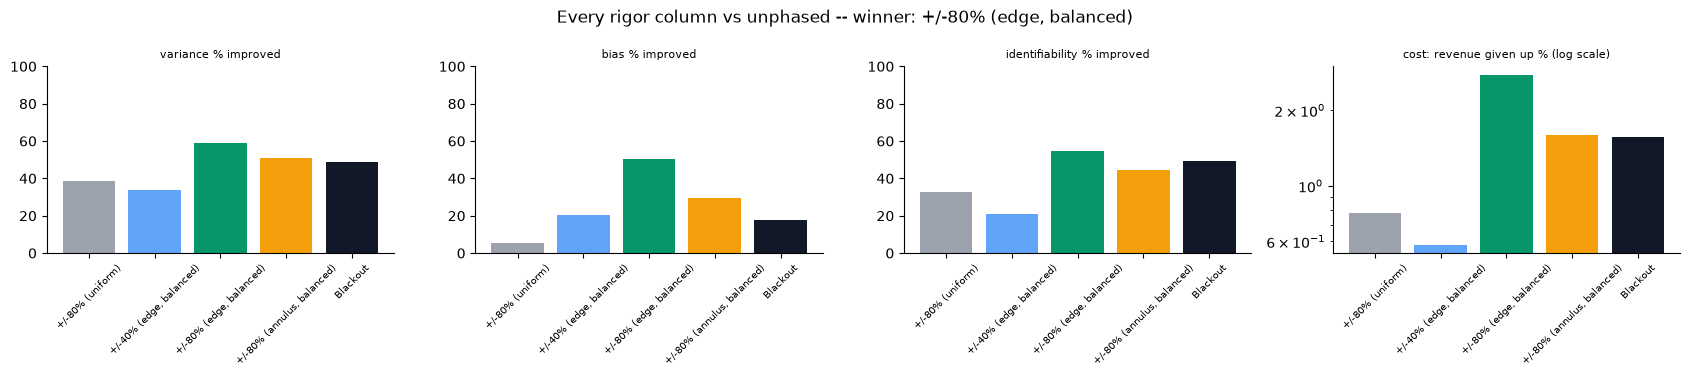

In [3]:
baseline_scores = report.results_["unphased"]["scores"]
impact_rows = []
for label in LEVER_ORDER[1:]:
    scores = report.results_[label]["scores"]
    impact_rows.append(
        {
            "lever": label,
            "variance % improved": 100
            * _safe_improvement(baseline_scores["variance"], scores["variance"]),
            "bias % improved": 100
            * _safe_improvement(baseline_scores["bias"], scores["bias"]),
            "identifiability % improved": 100
            * _safe_improvement(
                baseline_scores["identifiability"], scores["identifiability"]
            ),
            "cost: revenue given up %": cost_pct[label],
        }
    )
impact = pd.DataFrame(impact_rows).set_index("lever")
print(impact.round(1).to_string())

colors = {
    "+/-80% (uniform)": "#9ca3af",
    "+/-40% (edge, balanced)": "#60a5fa",
    "+/-80% (edge, balanced)": "#059669",
    "+/-80% (annulus, balanced)": "#f59e0b",
    "Blackout": "#111827",
}
panels = ["variance % improved", "bias % improved", "identifiability % improved"]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, col in zip(axes[:3], panels):
    vals = impact[col]
    ax.bar(vals.index, vals, color=[colors[lv] for lv in vals.index])
    ax.set_title(col, fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_ylim(0, 100)
ax = axes[3]
vals = impact["cost: revenue given up %"]
ax.bar(vals.index, vals, color=[colors[lv] for lv in vals.index])
ax.set_title("cost: revenue given up % (log scale)", fontsize=8)
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=45, labelsize=7)
fig.suptitle(f"Every rigor column vs unphased -- winner: {report.winner_}")
plt.tight_layout()
plt.show()

## Bringing it together

**`+/-80% (edge, balanced)` dominates all three rigor axes outright**, in
this scenario too: best variance improvement (58.7% vs `annulus`'s
next-best 51.0%), best bias removal (50.3% vs `annulus`'s 29.4%), and best
identifiability (54.7% vs Blackout's 49.2%). `DiscoveryReport` picks it as
winner for exactly that reason (`_pick_winner`'s dominance check finds one
candidate on top of all three axes, not a coin flip).

**The cost picture has flipped from the old (pre-curvature-aware,
3-channel) version of this comparison.** There, `edge+balanced+80%` was
both the rigor winner and cheaper than Blackout (8.89% vs 9.92% of
revenue). Here, on the current per-channel saturation/adstock scenario
(notebook 01's canonical TV/Meta/Search Generic/TikTok economics), it is
the *most* expensive of the five candidates: 2.77% of revenue given up,
against Blackout's 1.57%, `annulus`'s 1.60%, `uniform`'s 0.78%, and
`edge+40%`'s 0.58%. Rigor dominance still holds; "and it costs less too"
does not -- under real, per-channel saturation this is a genuine trade-off,
not a free upgrade, and `overview.html`'s phasing section should say so
rather than repeat the old cost claim.

**`annulus, balanced` looks more competitive here than the old notebook
found it.** At the same cost as Blackout (1.6% each), it beats Blackout on
variance (51.0% vs 48.9%) and bias (29.4% vs 17.8%), losing only narrowly
on identifiability (44.3% vs 49.2%). Worth a second look as a practical
middle option rather than dismissed the way the old, less curvature-aware
comparison dismissed it.

**Cheapest lever with real rigor: `+/-40% (edge, balanced)`**, at 0.58%
cost -- cheaper even than `+/-80% (uniform)`'s 0.78% -- while already
narrowing variance by a third (33.6%) and identifiability by a fifth
(20.8%). For a client unwilling to pay `edge+80%`'s cost, this is the
fallback worth quoting, not a lower-intensity `uniform` range.